# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [1]:
from __future__ import annotations

%pip install -q "torch-fidelity>=0.3,<1.0"
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.6 MB/s eta 0:00:00


In [2]:
import os
import shutil
from google.colab import drive

# 1. Pulisci forzatamente la cartella incriminata
if os.path.exists('/content/drive'):
    print("Rimozione della cartella locale /content/drive per liberare il mountpoint...")
    try:
        shutil.rmtree('/content/drive')
        print("Pulizia completata.")
    except Exception as e:
        print(f"Errore durante la pulizia: {e}. Provo a rinominarla.")
        os.rename('/content/drive', '/content/drive_backup')

# 2. Ora riprova il mount
print("Tentativo di mount in corso...")
drive.mount('/content/drive', force_remount=True)

# 3. Solo se il mount ha successo, procedi con l'unzip LOCALE
if os.path.exists('/content/drive/MyDrive'):
    print("✅ Drive montato correttamente!")
    !mkdir -p /content/artbench_local
    !unzip -o -q "/content/drive/MyDrive/GenerativeAI/GenAI_Project/TP1-alunos-src-only/ArtBench-10.zip" -d "/content/artbench_local"
    print("🚀 Dataset scompattato in locale!")
else:
    print("❌ Il mount è fallito o il percorso 'MyDrive' non è visibile.")

Mounted at /content/drive
✅ Drive montato correttamente!
🚀 Dataset scompattato in locale!


In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device:', device)

Device: cuda


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/TP1-alunos-src-only').resolve()
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

PROJECT_ROOT = /content/drive/.shortcut-targets-by-id/1D5marWek97vM4aPSOqX6PyweONel1WI9/GenerativeAI/GenAI_Project/TP1-alunos-src-only
KAGGLE_ROOT  = /content/drive/.shortcut-targets-by-id/1D5marWek97vM4aPSOqX6PyweONel1WI9/GenerativeAI/GenAI_Project/TP1-alunos-src-only/ArtBench-10


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
# Map images folders into manage objects, and CSV files into HuggingFace Datasets
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]
test_hf = hf_ds["test"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

print("Test size:", len(test_hf))
print("Columns   :", test_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='/content/drive/.shortcut-targets-by-id/1D5marWek97vM4aPSOqX6PyweONel1WI9/GenerativeAI/GenAI_Project/TP1-alunos-src-only/ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Test size: 10000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [9]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


"""
Take original dataset and wrap it into a PyTorch Dataset, applying the transform on the fly.
"""
class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


"""
Make a subset of indices for a dataset.
"""
def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    # Compute the number of samples to keep based on the fraction
    n_keep = max(1, int(round(n_total * fraction)))
    # For reproducibility, use a seeded random generator to shuffle indices
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

# Wrap the HuggingFace dataset into a PyTorch Dataset, applying the transform on the fly.
train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [7]:
import csv

"""
Load training IDs from a CSV file.
"""

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/TP1-alunos-src-only/student_start_pack/training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


### Build dataloaders for both AE/VAE and GAN

In [8]:
def build_artbench_loaders(
    train_hf,
    test_hf,
    batch_size=BATCH_SIZE,
    use_gan_norm=False,
    train_ids=None,
    image_size=IMAGE_SIZE
):
    
    # Manage the AE/VAE and the GAN normalization differences with a simple transform switch
    if use_gan_norm:
        transform = T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(image_size),
        T.ToTensor(),  # outputs [0,1]
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]   
        ])
        print("Preprocessing: using GAN/Diffusion normalization ([-1,1])")
    else:
        transform = T.Compose([
            T.Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
            T.CenterCrop(image_size),
            T.ToTensor(),  # outputs [0,1]
        ])
        print("Preprocessing: using AE/VAE normalization ([0,1])")
    
    train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_ids)
    test_ds = HFDatasetTorch(test_hf, transform=transform)

    effective_workers = safe_num_workers(NUM_WORKERS)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=effective_workers,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=effective_workers,
    )

    return train_loader, test_loader

## Visualize a sample grid

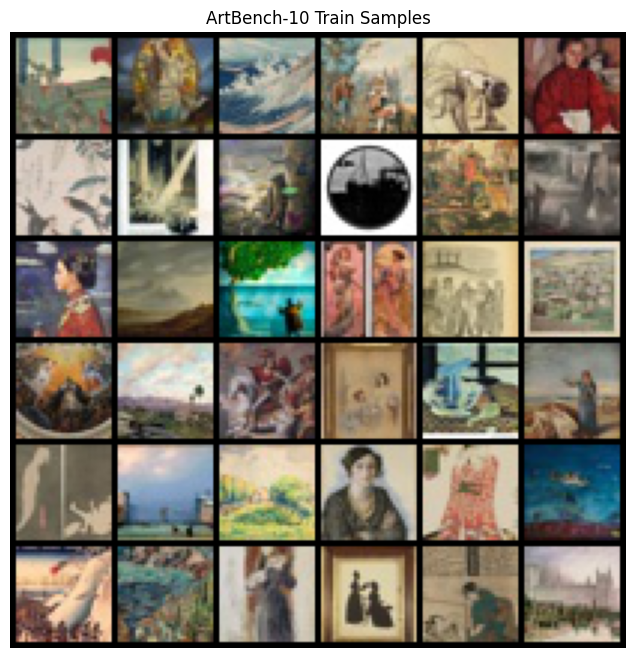

Labels: ['ukiyo_e', 'surrealism', 'ukiyo_e', 'realism', 'impressionism', 'art_nouveau', 'ukiyo_e', 'art_nouveau', 'surrealism', 'art_nouveau', 'post_impressionism', 'surrealism', 'impressionism', 'baroque', 'surrealism', 'art_nouveau', 'art_nouveau', 'art_nouveau', 'baroque', 'impressionism', 'baroque', 'romanticism', 'expressionism', 'romanticism', 'ukiyo_e', 'realism', 'post_impressionism', 'art_nouveau', 'ukiyo_e', 'surrealism', 'ukiyo_e', 'expressionism', 'impressionism', 'romanticism', 'ukiyo_e', 'romanticism']


In [11]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [12]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


#### Helper Functions

In [13]:
import json
from pathlib import Path
import torch

MODEL_DIR = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models')
HISTORY_DIR = Path('/content/drive/MyDrive/GenerativeAI/GenAI_Project/History')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

USED_SAVED_IF_EXISTS = True

def slugify_name(str) -> str:
    stem = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str)
    stem = '_'.join(part for part in stem.split('_') if part)
    return stem or 'model'

def path_for_model(model_name: str) -> Path:
    stem = slugify_name(model_name)
    return MODEL_DIR / f"{stem}.pth", HISTORY_DIR / f"{stem}_history.json"

def fit_or_load_model(model, name, train_function, load_if_available=USED_SAVED_IF_EXISTS, **train_kwargs):
    
    model_path, history_path = path_for_model(name)

    if load_if_available and model_path.exists() and history_path.exists():
        print(f"Upload model \"{name}\" from: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
        with open(history_path, 'r', encoding='utf-8') as f:
            history = json.load(f)
        return history
    

    # --- TRAINING (if file doesn't exists or if we want to retrain) ---
    print(f'Model "{name}" not found or retraining. Start training...')
    history = train_function(model=model, **train_kwargs)

    # Save weights
    with model_path.open('wb') as f:
        torch.save(model.state_dict(), f)
    
    # Save history
    with history_path.open('w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)
    torch.save(model.state_dict(), model_path)
    with open(history_path, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)

    print(f'Model saved in: {model_path}')
    print(f'History saved in: {history_path}')
    return history


### Helpers for GANs

In [15]:
def save_gan_model(generator, discriminator, history, cfg, ckpt_dir):
    checkpoint_path = Path(ckpt_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)

    file_name = checkpoint_path / f"{cfg['name']}.pth"
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': cfg
        }, file_name)
    
    print(f"Model saved at: {file_name}")

def denorm(x):
    # Convert from [-1, 1] to [0, 1]
    return (x + 1.0) / 2.0


### Save best model to Google Drive

In [36]:
def save_best(model_type_name, weights, history, config):
    models_path = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models")
    history_path = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/History")
    best_configs = Path("/content/drive/MyDrive/GenerativeAI/GenAI_Project/BestConfigs")
    
    models_path.mkdir(parents=True, exist_ok=True)
    history_path.mkdir(parents=True, exist_ok=True)
    best_configs.mkdir(parents=True, exist_ok=True)

    model_name = f"best_{model_type_name}"

    # Save weights
    torch.save(weights, models_path / f"{model_name}.pth")

    # Save config
    with open(best_configs / f"{model_name}_config.json", "w") as f:
        json.dump(config, f, indent=4)
    
    # Save history
    with open(history_path / f"{model_name}_history.json", "w") as f:
        json.dump(history, f, indent=4)
    
    print(f"\n" + "="*40)
    print(f"MODEL '{model_name}' SAVED!")
    print(f"Weights:    {models_path}")
    print(f"Config:  {best_configs}")
    print(f"History: {history_path}")
    print("="*40)



## AUTOENCODERS

#### Model Comparison: Dense vs. Convolutional AutoEncoders

In this section, we evaluate and compare the performance of two different architectures—the Dense Autoencoder (DenseAE) and the Convolutional Autoencoder (ConvAE)—on the ArtBench-10 dataset. Our primary goal is to analyze how architectural choices impact the model's ability to compress and reconstruct complex artistic styles within a shared 128-dimensional latent space.

### DenseAutoencoder

The **DenseAE** is built using linear layers (FullyConnected layers). It treats the image data as flat list of numbers, ignoring the 2D structure of the image (32x32).

#### 1) ENCODER (Compression)
- **Input**: It takes the 3D image (3 x 32 x 32) and flattens it into a 1D vector of **3072 elements**
- **Hidden Layers**: The data passes through 3 layers to reduce the dimension(1024 -> 512 -> 256)
- **Bottleneck**: It reaches te latent space (128). At this stage the image is reduced to a simple list of numbers, losing all spatial coordinates of the original pixels

#### 2) DECODER (Reconstruction)
- **Expansion**: It reverses the process (256 -> 512 -> 1024 -> 3072)
- **Output**: It produces a flat vector of 3072 values, which is reshaped back into a 3x32x32 image

In [16]:
INPUT_DIM = 3 * IMAGE_SIZE * IMAGE_SIZE


class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim = INPUT_DIM, hidden_dims= (1024, 512, 256), latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], INPUT_DIM),
            nn.Sigmoid()  # output in [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [17]:
def train_autoencoder(model, dataloader, optimizer, num_epochs=20, flatten_input=True):
    model.train()
    history = []
    for epoch in range(num_epochs):
        run = 0.0
        for x, _, _ in dataloader:
            x = x.to(device)
            if flatten_input:
                x = x.view(x.size(0), -1)  # flatten to (B, 3*32*32)
            else:
                x = x  # keep as (B, 3, 32, 32)

            out = model(x)
            loss = F.mse_loss(out, x, reduction='mean')

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            run += loss.item() * x.size(0)

        epoch_loss = run / len(dataloader.dataset)
        history.append(epoch_loss)
        print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.6f}')
    return history

In [18]:
def evaluate_autoencoder(model, dataloader, flatten_input=True):
    model.eval()
    # compute mse and mae
    mse, mae = 0.0, 0.0
    n = 0

    with torch.no_grad():
        for x, _, _ in dataloader:
            x = x.to(device)
            if flatten_input:
                x = x.view(x.size(0), -1)  # flatten to (B, 3*32*32)
            else:
                x = x  # keep as (B, 3, 32, 32)

            out = model(x)
            mse += F.mse_loss(out, x, reduction='sum').item()
            mae += F.l1_loss(out, x, reduction='sum').item()
            n += x.size(0)
    numel = x[0].numel()  # number of elements per image
    return {'mse': mse / (n * numel), 'mae': mae / (n * numel)}

In [21]:
train_loader_ae, test_loader_ae = build_artbench_loaders(
    train_hf,
    test_hf,
    batch_size=BATCH_SIZE,
    use_gan_norm=False,
    train_ids=train_ids_from_csv,
    image_size=IMAGE_SIZE
)

denseAE = DenseAutoencoder().to(device)
optimizer = torch.optim.Adam(denseAE.parameters(), lr=1e-3)
history = fit_or_load_model(
    model=denseAE,
    name="DenseAutoencoder",
    train_function= train_autoencoder,
    dataloader=train_loader_ae,
    optimizer=optimizer,
    num_epochs=20,
    flatten_input=True,
    load_if_available=True
)


Preprocessing: using AE/VAE normalization ([0,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Model "DenseAutoencoder" not found or retraining. Start training...
Epoch 1/20 - Loss: 0.036833
Epoch 2/20 - Loss: 0.029263
Epoch 3/20 - Loss: 0.028014
Epoch 4/20 - Loss: 0.026417
Epoch 5/20 - Loss: 0.024624
Epoch 6/20 - Loss: 0.024575
Epoch 7/20 - Loss: 0.024362
Epoch 8/20 - Loss: 0.023490
Epoch 9/20 - Loss: 0.022764
Epoch 10/20 - Loss: 0.022287
Epoch 11/20 - Loss: 0.021209
Epoch 12/20 - Loss: 0.020862
Epoch 13/20 - Loss: 0.020812
Epoch 14/20 - Loss: 0.020514
Epoch 15/20 - Loss: 0.020073
Epoch 16/20 - Loss: 0.019792
Epoch 17/20 - Loss: 0.019297
Epoch 18/20 - Loss: 0.019026
Epoch 19/20 - Loss: 0.018959
Epoch 20/20 - Loss: 0.019064
Model saved in: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/denseautoencoder.pth
History saved in: /content/drive/MyDrive/GenerativeAI/GenAI_Project/History/denseautoencoder_history.json


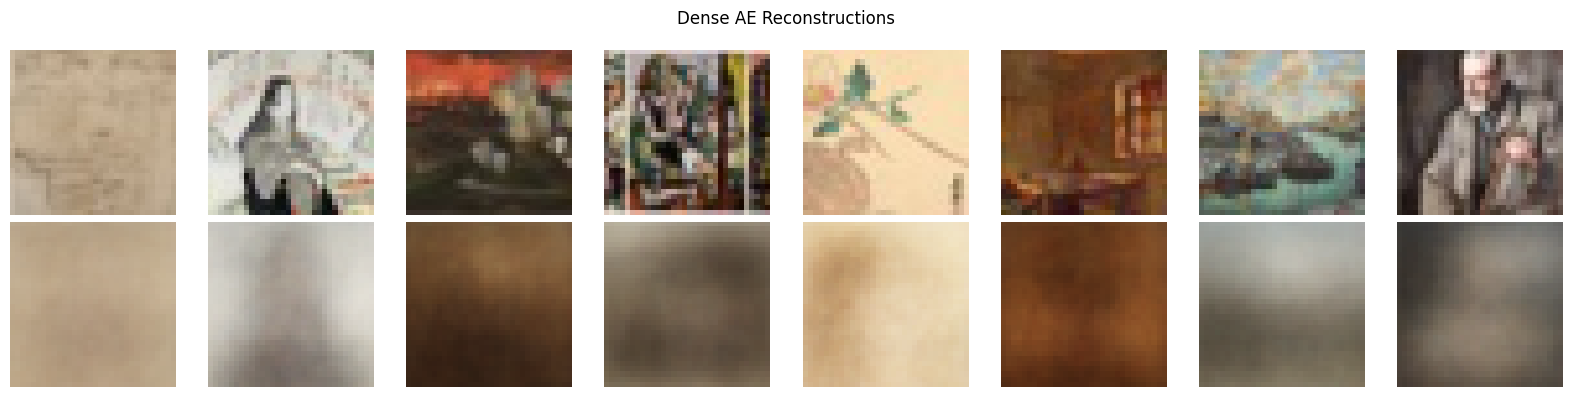

In [23]:
def show_reconstructions(model, dataloader, flatten_input, n_images=8, title="Dense AE Reconstructions"):
    model.eval()
    x, _, _ = next(iter(dataloader))
    x = x.to(device)
    
    xin = x.view(x.size(0), -1) if flatten_input else x
    
    with torch.no_grad():
        out = model(xin)
    
    if flatten_input:
        out = out.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)  # reshape back to images
    

    x = x[:n_images].cpu()
    out = out[:n_images].cpu()

    fig, axes = plt.subplots(2, n_images, figsize=(n_images * 2, 4))
    for i in range(n_images):
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[1, i].imshow(out[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[0,i].axis('off')
        axes[1,i].axis('off')
    axes[0,0].set_ylabel('Original', fontsize=12)
    axes[1,0].set_ylabel('Reconstructed', fontsize=12)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_reconstructions_vae(model, dataloader, n_images=8, title="VAE Reconstructions"):
    model.eval()
    x, _, _ = next(iter(dataloader))
    x = x.to(device)
    
    with torch.no_grad():
        out, _, _ = model(x)
    
    if x.dim() == 2:
        x = x.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)
    if out.dim() == 2:
        out = out.view(-1, 3, IMAGE_SIZE, IMAGE_SIZE)
    

    x = x[:n_images].cpu()
    out = out[:n_images].cpu()

    fig, axes = plt.subplots(2, n_images, figsize=(n_images * 2, 4))
    for i in range(n_images):
        axes[0, i].imshow(x[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[1, i].imshow(out[i].permute(1, 2, 0).numpy().clip(0, 1))
        axes[0,i].axis('off')
        axes[1,i].axis('off')
    axes[0,0].set_ylabel('Original', fontsize=12)
    axes[1,0].set_ylabel('Reconstructed', fontsize=12)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



show_reconstructions(denseAE, test_loader_ae, flatten_input=True, n_images=8, title="Dense AE Reconstructions")


### Analysis of DenseAE Reconstructions
The visualization above compares the **original images** (top row) from the ArtBench-10 dataset with their **reconstructions** (bottom row) produced by the DenseAE.
#### Key Observations
- **Loss of High-Frequency Details**: The reconstructed images appear blurred. This is a classic limitation of **Dense (Fully Connected Layers)**, which treat every pixel as an independent input and fail to capture spatial informations (local patterns)
- **Mean Color Approximation**: The DenseAE tends to predice the *average* color of a specific region.
- **Global Structure**: DenseAE manages to recover the general composition (as we can see it only captures the main color of the image)

### Convolutional AutoEncoder
The **ConvAE** uses *Conv2d* and *ConvTranspose2d* layers. Instead of flattening the image immediately, it uses filters to scan the image surface

#### 1) ENCODER (Feature Extraction)
- **Input**: It preserves the 3D shape of the images
- **Convolutions**: Filters slide across the image to detect edges, textures and shapes. By using a stride of 2, the image size is reduced by a factor of 2 on each step while the feature maps increases. 

#### 2) DECODER (Upsampling)
- **Transposed Convolutions**: It uses "Deconvolutions" to reverse the shrinkage. 
- **Symmetry**: It reconstructs the resolution step-by-step (4 -> 8 -> 16 -> 32), ensuring that the spatial coherence is maintained.

In [24]:
#3 input channels and 3 output channels for RGB images
# images are 32x32x3
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    def __init__(self, latent_dim=128, base_filters=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.base_filters = base_filters

        self.encoder = nn.Sequential(
            # input is (B, 3, 32, 32)
            # output after conv1: (B, 32, 16, 16)
            nn.Conv2d(3, base_filters, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(base_filters), 
            nn.ReLU(),

            # input is (B, 32, 16, 16)
            # output after conv2: (B, 64, 8, 8)
            nn.Conv2d(base_filters, base_filters*2, kernel_size=3, stride=2, padding=1),   
            nn.BatchNorm2d(base_filters*2),
            nn.ReLU(),

            # input is (B, 64, 8, 8)
            # output after conv3: (B, 128, 4, 4)
            nn.Conv2d(base_filters*2, base_filters*4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(base_filters*4),
            nn.ReLU(),

        )

        # Latent space
        self.enc_fc = nn.Linear(base_filters*4 * 4 * 4, latent_dim)


        # Decoder: recover the image from latent space
        self.decoder_input = nn.Linear(latent_dim, base_filters*4 * 4 * 4)
        self.decoder = nn.Sequential(
            # input is (B, 128, 4, 4)
            # output after convT1: (B, 64, 8, 8)
            nn.ConvTranspose2d(base_filters*4, base_filters*2, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 8x8
            nn.ReLU(),

            # input is (B, 64, 8, 8)
            # output after convT2: (B, 3, 32, 32)
            nn.ConvTranspose2d(base_filters*2, base_filters, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 32x32
            nn.ReLU(),

            # input is (B, 32, 32, 32)
            # output after convT3: (B, 3, 64, 64)
            nn.ConvTranspose2d(base_filters, 3, kernel_size=3, stride=2, padding=1, output_padding=1),   # -> 64x64 (will be cropped to 32x32)
            nn.Sigmoid()  # output in [0,1]
        )


    def encode(self, x):
        h = self.encoder(x)

        h = h.view(h.size(0), -1)  # flatten
        z = self.enc_fc(h)
        return z

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.base_filters*4, 4, 4)  # reshape to (B, 128, 4, 4)
        out = self.decoder(h)
        return out
    
    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out


In [31]:
import itertools
# Try with different parameters
search_space = {
    'z': [128, 256],
    'lr': [1e-3, 5e-4],
    'filters': [32, 64, 128],
    'epochs': [20, 30],
}

keys = search_space.keys()
values = search_space.values()

combinations = list(itertools.product(*values))
print(f"Total combinations to try: {len(combinations)}")

ae_configs = []
for combo in combinations:
    # Create a dictiornary for each combination
    config = dict(zip(keys, combo))
    config['name'] = f"ConvAE_z{config['z']}_lr{config['lr']}_f{config['filters']}_e{config['epochs']}"
    ae_configs.append(config)

print("All configurations:")
for cfg in ae_configs:
    print(f" - {cfg['name']}")

Total combinations to try: 24
All configurations:
 - ConvAE_z128_lr0.001_f32_e20
 - ConvAE_z128_lr0.001_f32_e30
 - ConvAE_z128_lr0.001_f64_e20
 - ConvAE_z128_lr0.001_f64_e30
 - ConvAE_z128_lr0.001_f128_e20
 - ConvAE_z128_lr0.001_f128_e30
 - ConvAE_z128_lr0.0005_f32_e20
 - ConvAE_z128_lr0.0005_f32_e30
 - ConvAE_z128_lr0.0005_f64_e20
 - ConvAE_z128_lr0.0005_f64_e30
 - ConvAE_z128_lr0.0005_f128_e20
 - ConvAE_z128_lr0.0005_f128_e30
 - ConvAE_z256_lr0.001_f32_e20
 - ConvAE_z256_lr0.001_f32_e30
 - ConvAE_z256_lr0.001_f64_e20
 - ConvAE_z256_lr0.001_f64_e30
 - ConvAE_z256_lr0.001_f128_e20
 - ConvAE_z256_lr0.001_f128_e30
 - ConvAE_z256_lr0.0005_f32_e20
 - ConvAE_z256_lr0.0005_f32_e30
 - ConvAE_z256_lr0.0005_f64_e20
 - ConvAE_z256_lr0.0005_f64_e30
 - ConvAE_z256_lr0.0005_f128_e20
 - ConvAE_z256_lr0.0005_f128_e30


In [37]:
# Dizionario per raccogliere tutti i risultati
all_results = {}
idx = 1

# Set variables to figure out the best model
best_model_name = None
best_mse = float('inf')
# for save the weights of the best model
best_model_weights = None
# for save the history of the best model
best_model_history = None  
for cfg in ae_configs:
    print(f"\nCONFIGURATION: {idx}/{len(ae_configs)} === Training {cfg['name']} ===")
    idx += 1
    model = ConvAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    
    history = fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function=train_autoencoder,
        dataloader=train_loader_ae,
        optimizer=optimizer,
        num_epochs=cfg['epochs'],
        load_if_available=True,
        flatten_input=False
    )
    
    metrics = evaluate_autoencoder(model, test_loader_ae, flatten_input=False)
    all_results[cfg['name']] = {
        'history': history,
        'metrics': metrics
    }

    current_mse = metrics['mse']

    # Find the best model based on MSE
    if current_mse < best_mse:
        best_mse = current_mse
        best_model_info = cfg
        best_model_weights = model.state_dict()  # save the weights of the best model
        best_model_history = history  # save the history of the best model
    print(f"Metrics for {cfg['name']}: {metrics}")

    del model
    torch.cuda.empty_cache()

# --- Print the best model information ---
print("\n" + "="*30)
print(f"BEST MODEL: {best_model_info['name']}")
print(f"BEST MSE: {best_mse:.6f}")
print("="*30)

# Save the best model to Google Drive
save_best(
    model_type_name="ConvAE",
    weights=best_model_weights,
    history=best_model_history,
    config=best_model_info
)



CONFIGURATION: 1/24 === Training ConvAE_z128_lr0.001_f32_e20 ===
Upload model "ConvAE_z128_lr0.001_f32_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e20.pth
Metrics for ConvAE_z128_lr0.001_f32_e20: {'mse': 0.0063271274507045745, 'mae': 0.05749422928492228}

CONFIGURATION: 2/24 === Training ConvAE_z128_lr0.001_f32_e30 ===
Upload model "ConvAE_z128_lr0.001_f32_e30" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e30.pth
Metrics for ConvAE_z128_lr0.001_f32_e30: {'mse': 0.005986534798145295, 'mae': 0.056043941601117454}

CONFIGURATION: 3/24 === Training ConvAE_z128_lr0.001_f64_e20 ===
Upload model "ConvAE_z128_lr0.001_f64_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f64_e20.pth
Metrics for ConvAE_z128_lr0.001_f64_e20: {'mse': 0.0059970173060894015, 'mae': 0.05586657073497772}

CONFIGURATION: 4/24 === Training ConvAE_z128_lr0.001_f64_e30 ===
Upload model "ConvAE_z

#### Computation of FID and KID for best model understading

In [ ]:
N_SAMPLES = 2000
all_fid_results = {}
idx = 0

real_images = collect_real_images_from_loader(train_loader_from_csv, max_images=N_SAMPLES)
real_uint8 = to_uint8_artbench10(real_images)

print("\n=== FID/KID Evaluation ===")
for cfg in ae_configs:
    idx += 1
    print(f"\n CONFIGURATION: {idx}/{len(ae_configs)} -- Evaluating {cfg['name']} ---")

    model = ConvAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function= None,
        load_if_available=True
    )

    gen_images = sample_from_AE(model, train_loader_from_csv, images=N_SAMPLES)
    gen_uint8 = to_uint8_artbench10(gen_images)

    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)
    all_fid_results[cfg['name']] = {
        'fid': fid_val,
        'kid': kid_val
    }

    del model
    torch.cuda.empty_cache()

# --- PRINT FINAL TABLE ABOUT FID/KID METRICS ---
print("\n" + "="*60)
print(f"{'CONFIGURATION':<25} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 60)
for name, res in all_fid_results.items():
    print(f"{name:<25} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*60)



=== FID/KID Evaluation ===

 CONFIGURATION: 1/24 -- Evaluating ConvAE_z128_lr0.001_f32_e20 ---
Upload model "ConvAE_z128_lr0.001_f32_e20" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e20.pth


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig


 CONFIGURATION: 2/24 -- Evaluating ConvAE_z128_lr0.001_f32_e30 ---
Upload model "ConvAE_z128_lr0.001_f32_e30" from: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_001_f32_e30.pth


### Comparison plot
I make a comparison between:
- real images
- best model
- worst model

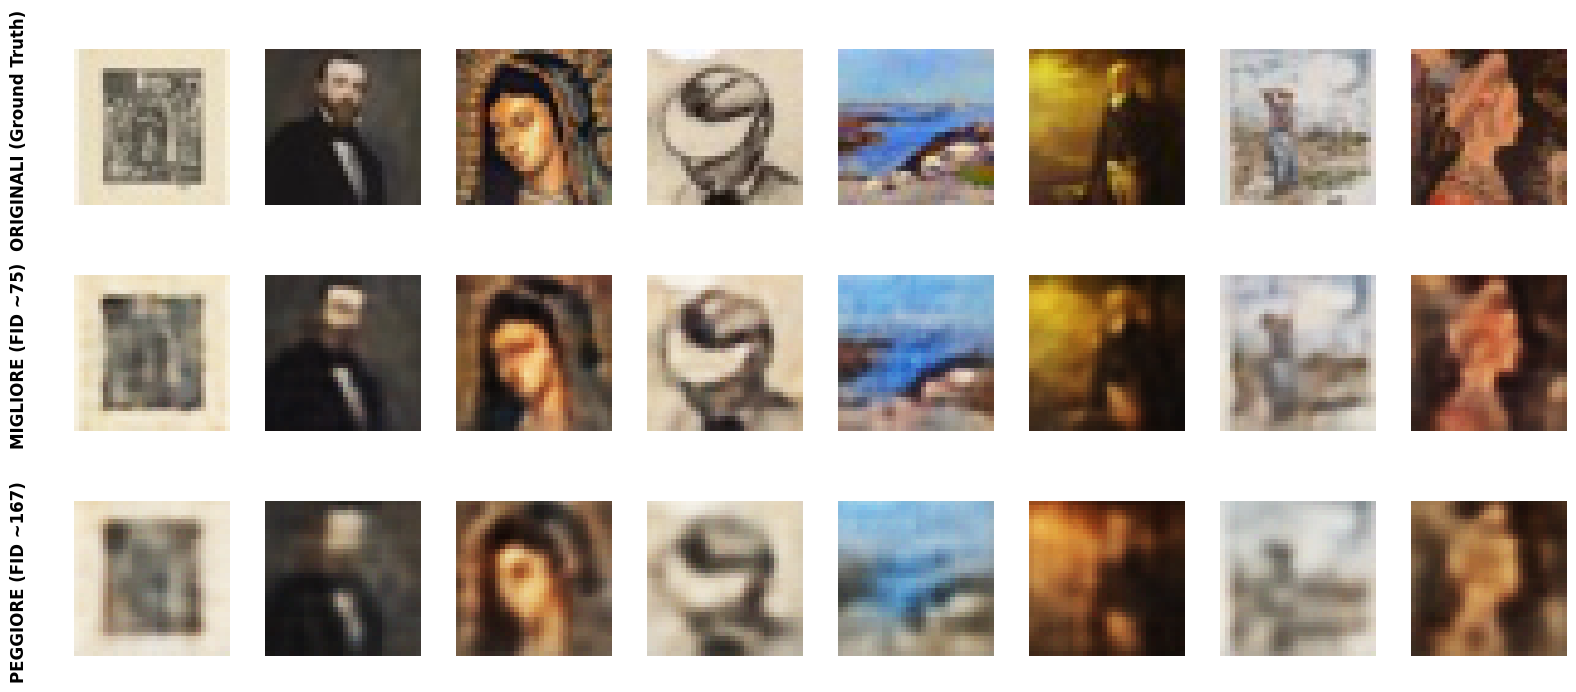

In [28]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def triple_visual_comparison(best_model, worst_model, loader, n_images=8, device="cuda"):
    best_model.eval()
    worst_model.eval()
    
    # 1. Prendiamo un batch di immagini reali
    images, _, _ = next(iter(loader))
    images = images[:n_images].to(device)
    
    with torch.no_grad():
        # 2. Ricostruzione del Migliore
        encoded_best = best_model.encode(images)
        reconst_best = best_model.decode(encoded_best)
        
        # 3. Ricostruzione del Peggiore
        encoded_worst = worst_model.encode(images)
        reconst_worst = worst_model.decode(encoded_worst)
            
    # Conversione per il plotting (da Tensor a Numpy HxWxC)
    def to_np(img_tensor):
        img = img_tensor.cpu().numpy().transpose(0, 2, 3, 1)
        return np.clip(img, 0, 1)

    real_np = to_np(images)
    best_np = to_np(reconst_best)
    worst_np = to_np(reconst_worst)

    # 4. Creazione della Figura (3 righe)
    fig, axes = plt.subplots(nrows=3, ncols=n_images, figsize=(n_images * 2, 7))
    
    titles = ["ORIGINALI (Ground Truth)", "MIGLIORE (FID ~75)", "PEGGIORE (FID ~167)"]
    data = [real_np, best_np, worst_np]

    for row in range(3):
        for col in range(n_images):
            axes[row, col].imshow(data[row][col])
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].text(-10, 16, titles[row], rotation=90, 
                                   va='center', ha='right', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()

# Esempio:
# 1. Recuperiamo il MIGLIORE (z256, f64, lr 0.001)
best_model = ConvAE(latent_dim=256, base_filters=64).to(device)
best_model.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z256_lr0_001_f64_e30.pth'))

# 2. Recuperiamo il PEGGIORE (z128, f32, lr 0.0005)
# (Dallo screenshot, f32 a e20 con lr 0.0005 era tra i più alti)
worst_model = ConvAE(latent_dim=128, base_filters=32).to(device)
worst_model.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convae_z128_lr0_0005_f32_e20.pth'))
triple_visual_comparison(best_model, worst_model, train_loader_from_csv, n_images=8, device=device)

### VARIATIONAL AUTOENCODERS

In [29]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128, base_filters=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.base_filters = base_filters

        # ENCODER
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, base_filters, 3, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(base_filters), 
            nn.ReLU(),
            nn.Conv2d(base_filters, base_filters*2, 3, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(base_filters*2), 
            nn.ReLU(),
            nn.Conv2d(base_filters*2, base_filters*4, 3, stride=2, padding=1),# -> 4x4
            nn.BatchNorm2d(base_filters*4), 
            nn.ReLU(),
        )

        # LATENT SPACE 
        self.fc_mu = nn.Linear(base_filters*4 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(base_filters*4 * 4 * 4, latent_dim)

        # DECODER: Ricostruisce partendo dal campionamento
        self.decoder_input = nn.Linear(latent_dim, base_filters*4 * 4 * 4)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(base_filters*4, base_filters*2, 3, stride=2, padding=1, output_padding=1), # -> 8x8
            nn.BatchNorm2d(base_filters*2), 
            nn.ReLU(),
            nn.ConvTranspose2d(base_filters*2, base_filters, 3, stride=2, padding=1, output_padding=1),  # -> 16x16
            nn.BatchNorm2d(base_filters), 
            nn.ReLU(),
            nn.ConvTranspose2d(base_filters, 3, 3, stride=2, padding=1, output_padding=1),   # -> 32x32
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)  # flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.base_filters*4, 4, 4)  # reshape to (B, 128, 4, 4)
        out = self.decoder_conv(h)
        return out
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        out = self.decode(z)
        return out, mu, logvar

Insert the dynamic variable for configurations

In [30]:
def vae_loss_function(recon_x, x, mu, logvar, beta = 1.0):
    # Errore di ricostruzione (quanto l'immagine somiglia all'originale)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL Divergence (spinge la distribuzione latente verso una normale standard)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = (recon_loss + beta * kl_loss)/x.size(0)  # normalizza per batch size
    
    return total_loss, recon_loss/x.size(0), kl_loss/x.size(0)

### Training Loop for VAE

In [39]:
def train_vae(model, dataloader, optimizer, beta = 0.7, num_epochs=20):
    
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kl_loss': []
    }
    
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        for x, _, _ in dataloader:
            x = x.to(device)

            #Forward pass
            recon_x, mu, logvar = model(x)

            # Calcolo Loss (Reconstruction + KL)
            loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            #Backpropagation and update weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # 3. Accumulo: trasformiamo la media del batch in somma totale del batch
            total_loss += loss.item() * x.size(0) 
            train_recon_loss += recon_loss.item() * x.size(0)
            train_kl_loss += kl_loss.item() * x.size(0)
        
        # Calcolo medie
        n = len(dataloader.dataset)
        avg_total = total_loss / n
        avg_recon = train_recon_loss / n
        avg_kl = train_kl_loss / n

        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_total:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")
    
    return history


In [42]:
def evaluate_vae(model, dataloader, beta=0.7):
    model.eval()
    total_loss = 0.0
    recon_loss = 0.0
    kl_loss = 0.0
    mse = 0.0
    mae = 0.0
    n = 0

    with torch.no_grad():
        for x, _, _ in dataloader:
            x = x.to(device)
            recon_x, mu, logvar = model(x)
            loss, recon, kl = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            total_loss += loss.item() * x.size(0)
            recon_loss += recon.item() * x.size(0)
            kl_loss += kl.item() * x.size(0)

            mse += F.mse_loss(recon_x, x, reduction='sum').item()
            mae += F.l1_loss(recon_x, x, reduction='sum').item()


            n += x.size(0)

    numel = x[0].numel()  # number of elements per image
    return {
        'total_loss': total_loss / n,
        'recon_loss': recon_loss / n,
        'kl_loss': kl_loss / n,
        'mse': mse / (n * numel),
        'mae': mae / (n * numel)
    }
    

In [43]:
vae_search_space = {
    'z': [128, 256],
    'lr': [1e-3, 5e-4],
    'filters': [32, 64],
    'epochs': [20],
    'beta': [0.1, 0.5, 0.7, 1.0]
}

# Generation of the configurations to try
keys = vae_search_space.keys()
values = vae_search_space.values()
combinations = list(itertools.product(*values))
vae_configs = []
for combo in combinations:
    config = dict(zip(keys, combo))
    config['name'] = f"ConvVAE_z{config['z']}_lr{config['lr']}_f{config['filters']}_e{config['epochs']}_b{config['beta']}"
    vae_configs.append(config)

print(f"Ready to test {len(vae_configs)} VAE configurations:")
print("All VAE configurations:")
for cfg in vae_configs:
    print(f" - {cfg['name']}")


Ready to test 32 VAE configurations:
All VAE configurations:
 - ConvVAE_z128_lr0.001_f32_e20_b0.1
 - ConvVAE_z128_lr0.001_f32_e20_b0.5
 - ConvVAE_z128_lr0.001_f32_e20_b0.7
 - ConvVAE_z128_lr0.001_f32_e20_b1.0
 - ConvVAE_z128_lr0.001_f64_e20_b0.1
 - ConvVAE_z128_lr0.001_f64_e20_b0.5
 - ConvVAE_z128_lr0.001_f64_e20_b0.7
 - ConvVAE_z128_lr0.001_f64_e20_b1.0
 - ConvVAE_z128_lr0.0005_f32_e20_b0.1
 - ConvVAE_z128_lr0.0005_f32_e20_b0.5
 - ConvVAE_z128_lr0.0005_f32_e20_b0.7
 - ConvVAE_z128_lr0.0005_f32_e20_b1.0
 - ConvVAE_z128_lr0.0005_f64_e20_b0.1
 - ConvVAE_z128_lr0.0005_f64_e20_b0.5
 - ConvVAE_z128_lr0.0005_f64_e20_b0.7
 - ConvVAE_z128_lr0.0005_f64_e20_b1.0
 - ConvVAE_z256_lr0.001_f32_e20_b0.1
 - ConvVAE_z256_lr0.001_f32_e20_b0.5
 - ConvVAE_z256_lr0.001_f32_e20_b0.7
 - ConvVAE_z256_lr0.001_f32_e20_b1.0
 - ConvVAE_z256_lr0.001_f64_e20_b0.1
 - ConvVAE_z256_lr0.001_f64_e20_b0.5
 - ConvVAE_z256_lr0.001_f64_e20_b0.7
 - ConvVAE_z256_lr0.001_f64_e20_b1.0
 - ConvVAE_z256_lr0.0005_f32_e20_b0.1
 - Co

In [45]:
"""convolutionalVAE = ConvVAE(latent_dim=128).to(device)
optimizer_vae = torch.optim.Adam(convolutionalVAE.parameters(), lr=1e-3)

total_loss = fit_or_load_model(
    model=convolutionalVAE,
    name="ConvVAE",
    train_function= train_vae,
    dataloader=train_loader_from_csv,
    optimizer=optimizer_vae,
    beta=0.7,
    epochs=20
)
#show_reconstructions_vae(convolutionalVAE, train_loader_from_csv, title='ConvVAE Reconstructions')"""

# Dizionario per raccogliere tutti i risultati del VAE
all_vae_results = {}
idx = 1

# Variabili per tracciare il miglior modello VAE (basandoci sulla Reconstruction Loss o MSE)
best_vae_name = None
best_vae_loss = float('inf')
best_vae_weights = None
best_vae_history = None
best_vae_info = None

for cfg in vae_configs: # Usiamo la lista vae_configs che abbiamo appena sistemato
    print(f"\nVAE CONFIGURATION: {idx}/{len(vae_configs)} === Training {cfg['name']} ===")
    idx += 1
    
    # 1. Istanza del modello con i filtri dinamici
    model = ConvVAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    
    # 2. Training o Caricamento
    # Nota: passiamo 'beta' e 'epochs' come argomenti extra
    history = fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function=train_vae,
        dataloader=train_loader_from_csv,
        optimizer=optimizer,
        num_epochs=cfg['epochs'],
        beta=cfg['beta'],           # <--- Fondamentale per il VAE
        load_if_available=True,    # Metti True se vuoi solo valutare modelli già pronti
    )
    
    # 3. Valutazione (usiamo una funzione specifica per VAE o adattiamo quella AE)
    # Assicurati che evaluate_vae calcoli l'MSE tra input e recon_x
    metrics = evaluate_vae(model, train_loader_from_csv, beta=cfg['beta']) 
    
    all_vae_results[cfg['name']] = {
        'history': history,
        'metrics': metrics,
        'config': cfg
    }

    # Usiamo l'MSE di ricostruzione per decidere il "migliore"
    current_mse = metrics['mse']

    if current_mse < best_vae_loss:
        best_vae_loss = current_mse
        best_vae_info = cfg
        best_vae_weights = model.state_dict()
        best_vae_history = history
        
    print(f"Metrics for {cfg['name']}: {metrics}")

    # 4. Pulizia memoria (essenziale per 32 configurazioni!)
    del model
    torch.cuda.empty_cache()

# --- Print del vincitore VAE ---
print("\n" + "="*40)
print(f"🏆 BEST VAE MODEL: {best_vae_info['name']}")
print(f"📊 Miglior MSE Ricostruzione: {best_vae_loss:.6f}")
print(f"🧪 Beta utilizzato: {best_vae_info['beta']}")
print("="*40)




VAE CONFIGURATION: 1/32 === Training ConvVAE_z128_lr0.001_f32_e20_b0.1 ===
✅ Caricato modello "ConvVAE_z128_lr0.001_f32_e20_b0.1" da: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_1.pth
Metrics for ConvVAE_z128_lr0.001_f32_e20_b0.1: {'total_loss': 35.78974115600586, 'recon_loss': 25.918944009399414, 'kl_loss': 98.70796772460938, 'mse': 0.008437156253059705, 'mae': 0.06794064149856567}

VAE CONFIGURATION: 2/32 === Training ConvVAE_z128_lr0.001_f32_e20_b0.5 ===
🚀 Modello "ConvVAE_z128_lr0.001_f32_e20_b0.5" non trovato o retraining forzato. Inizio addestramento...
Epoch 1/20 - Loss: 105.0520 (Recon: 92.7832, KL: 24.5375)
Epoch 2/20 - Loss: 78.3992 (Recon: 65.6732, KL: 25.4520)
Epoch 3/20 - Loss: 72.2697 (Recon: 59.7233, KL: 25.0928)
Epoch 4/20 - Loss: 67.6226 (Recon: 54.2734, KL: 26.6984)
Epoch 5/20 - Loss: 64.5645 (Recon: 50.7863, KL: 27.5564)
Epoch 6/20 - Loss: 63.2368 (Recon: 49.3206, KL: 27.8324)
Epoch 7/20 - Loss: 62.6200 (Recon: 48.4848, K

In [46]:
N_SAMPLES = 2000
all_fid_results = {}
idx = 0

real_images = collect_real_images_from_loader(train_loader_from_csv, max_images=N_SAMPLES)
real_uint8 = to_uint8_artbench10(real_images)

print("\n=== FID/KID Evaluation ===")
for cfg in vae_configs:
    idx += 1
    print(f"\n CONFIGURATION: {idx}/{len(vae_configs)} -- Evaluating {cfg['name']} ---")

    model = ConvVAE(latent_dim=cfg['z'], base_filters=cfg['filters']).to(device)
    fit_or_load_model(
        model=model,
        name=cfg['name'],
        train_function= None,
        load_if_available=True
    )

    gen_images = sample_from_VAE(model, images=N_SAMPLES)
    gen_uint8 = to_uint8_artbench10(gen_images)

    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)
    all_fid_results[cfg['name']] = {
        'fid': fid_val,
        'kid': kid_val
    }

    del model
    torch.cuda.empty_cache()

# --- STAMPA TABELLA FINALE ---
print("\n" + "="*60)
print(f"{'CONFIGURATION':<25} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 60)
for name, res in all_fid_results.items():
    print(f"{name:<25} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*60)



=== FID/KID Evaluation ===

 CONFIGURATION: 1/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b0.1 ---
✅ Caricato modello "ConvVAE_z128_lr0.001_f32_e20_b0.1" da: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_1.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



 CONFIGURATION: 2/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b0.5 ---
✅ Caricato modello "ConvVAE_z128_lr0.001_f32_e20_b0.5" da: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_5.pth

 CONFIGURATION: 3/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b0.7 ---
✅ Caricato modello "ConvVAE_z128_lr0.001_f32_e20_b0.7" da: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b0_7.pth

 CONFIGURATION: 4/32 -- Evaluating ConvVAE_z128_lr0.001_f32_e20_b1.0 ---
✅ Caricato modello "ConvVAE_z128_lr0.001_f32_e20_b1.0" da: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f32_e20_b1_0.pth

 CONFIGURATION: 5/32 -- Evaluating ConvVAE_z128_lr0.001_f64_e20_b0.1 ---
✅ Caricato modello "ConvVAE_z128_lr0.001_f64_e20_b0.1" da: /content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f64_e20_b0_1.pth

 CONFIGURATION: 6/32 -- Evaluating ConvVAE_z128_lr0.001_f64_e20_b0.5 ---
✅ Caricato mod

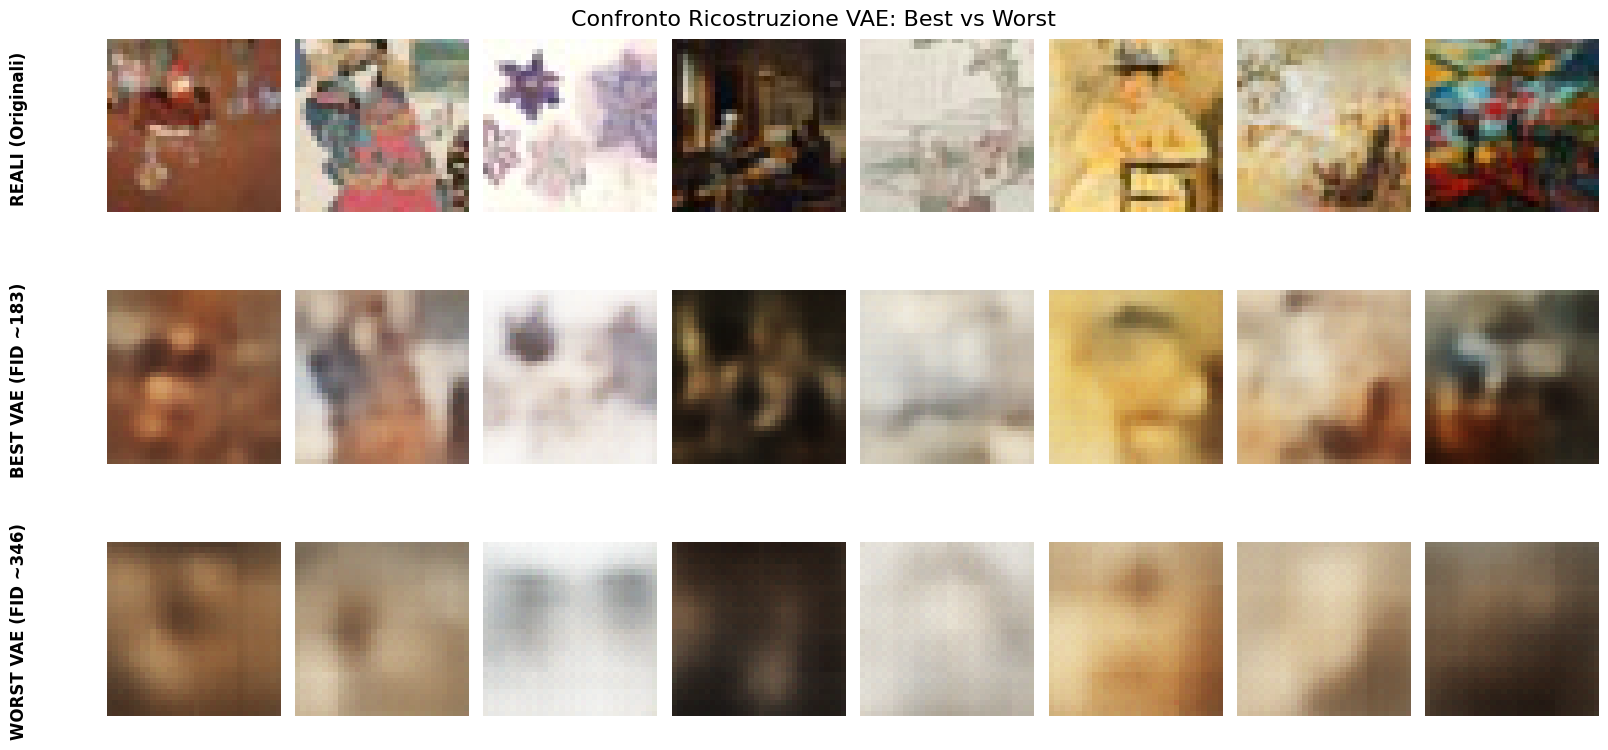

In [63]:
def triple_visual_comparison_vae(best_vae, worst_vae, loader, n_images=8, device="cuda"):
    best_vae.eval()
    worst_vae.eval()
    
    # 1. Prendiamo un batch di immagini reali
    # Assumiamo che il loader restituisca (immagini, etichette, percorsi)
    batch = next(iter(loader))
    images = batch[0][:n_images].to(device)
    
    with torch.no_grad():
        # 2. Ricostruzione del Migliore VAE
        # Il VAE ritorna (recon_batch, mu, logvar), noi prendiamo l'indice [0]
        reconst_best, _, _ = best_vae(images)
        
        # 3. Ricostruzione del Peggiore VAE
        reconst_worst, _, _ = worst_vae(images)
            
    # Funzione di utility per convertire i tensori in immagini numpy visualizzabili
    def to_np(img_tensor):
        img = img_tensor.cpu().numpy().transpose(0, 2, 3, 1)
        return np.clip(img, 0, 1)

    real_np = to_np(images)
    best_np = to_np(reconst_best)
    worst_np = to_np(reconst_worst)

    # 4. Creazione della Figura (3 righe)
    fig, axes = plt.subplots(nrows=3, ncols=n_images, figsize=(n_images * 2, 8))
    
    # Adatta i titoli con i tuoi FID reali del VAE
    titles = ["REALI (Originali)", "BEST VAE (FID ~183)", "WORST VAE (FID ~346)"]
    data = [real_np, best_np, worst_np]

    for row in range(3):
        for col in range(n_images):
            axes[row, col].imshow(data[row][col])
            axes[row, col].axis('off')
            if col == 0:
                # Titoli laterali per le righe
                axes[row, col].text(-15, 16, titles[row], rotation=90, 
                                   va='center', ha='right', fontweight='bold', fontsize=12)

    plt.suptitle("Confronto Ricostruzione VAE: Best vs Worst", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()


# 1. Carichiamo il MIGLIORE VAE (z128, f64, lr 0.001, beta 0.1)
best_vae = ConvVAE(latent_dim=128, base_filters=64).to(device)
best_vae.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_001_f64_e20_b0_1.pth'))

# 2. Carichiamo il PEGGIORE VAE (z256, f64, lr 0.001, beta 1.0)
worst_vae = ConvVAE(latent_dim=256, base_filters=64).to(device)
worst_vae.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z256_lr0_001_f64_e20_b1_0.pth'))

# 3. Lanciamo il confronto
triple_visual_comparison_vae(best_vae, worst_vae, train_loader_from_csv, n_images=8, device=device)

### Best AE vs Best VAE

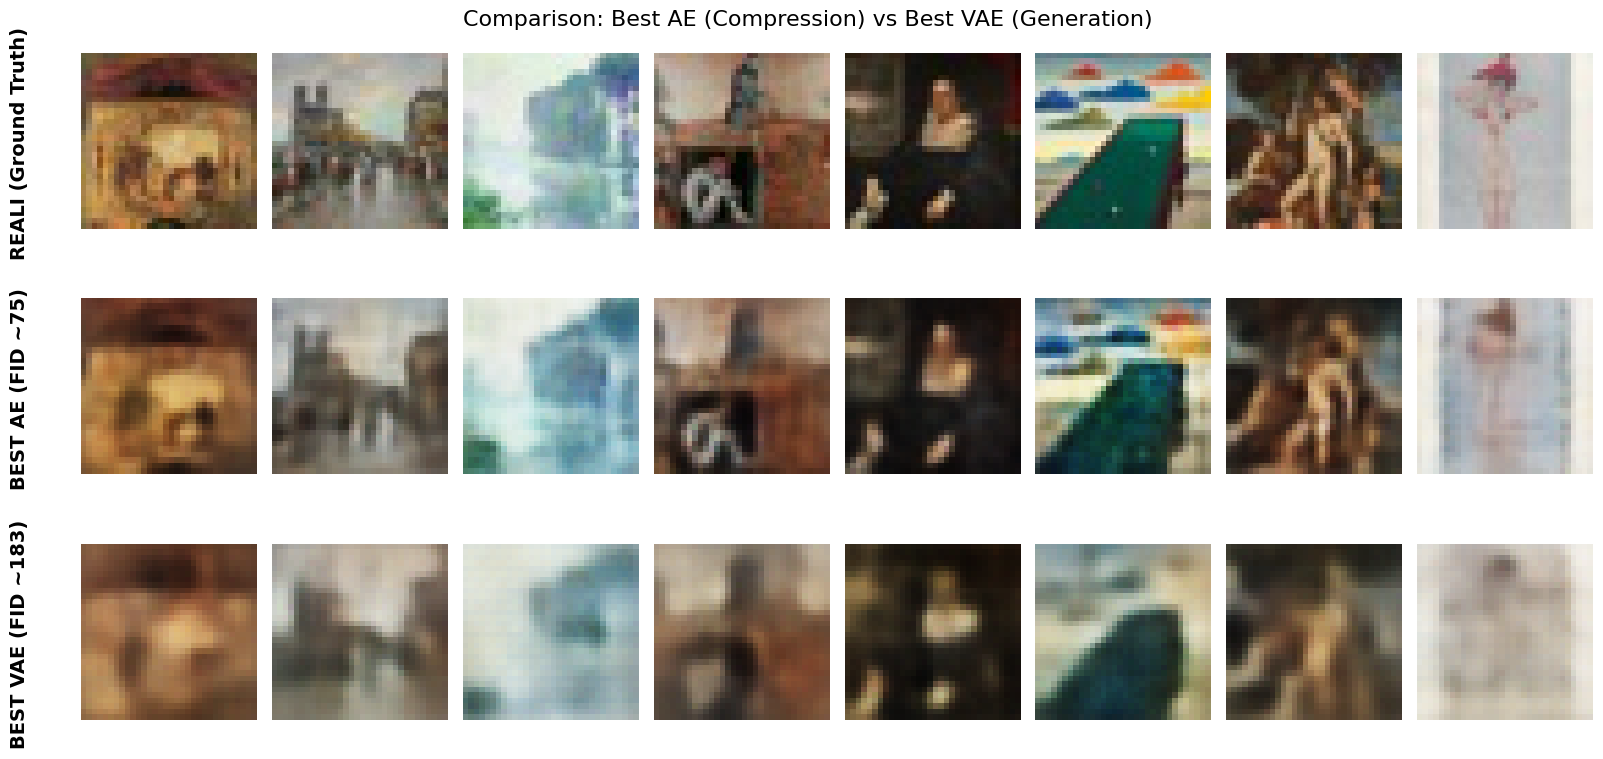

In [69]:
def compare_best_ae_vae(best_ae, best_vae, loader, n_images=8, device="cuda"):
    best_ae.eval()
    best_vae.eval()
    
    # 1. Prendiamo un batch di immagini reali
    batch = next(iter(loader))
    images = batch[0][:n_images].to(device)
    
    with torch.no_grad():
        # 2. Ricostruzione AE (Ritorna solo l'immagine)
        reconst_ae = best_ae(images)
        
        # 3. Ricostruzione VAE (Ritorna la tupla, prendiamo l'indice [0])
        reconst_vae, _, _ = best_vae(images)
            
    # Utility per conversione in Numpy
    def to_np(img_tensor):
        img = img_tensor.cpu().numpy().transpose(0, 2, 3, 1)
        return np.clip(img, 0, 1)

    real_np = to_np(images)
    ae_np = to_np(reconst_ae)
    vae_np = to_np(reconst_vae)

    # 4. Plotting
    fig, axes = plt.subplots(nrows=3, ncols=n_images, figsize=(n_images * 2, 8))
    
    titles = ["REALI (Ground Truth)", "BEST AE (FID ~75)", "BEST VAE (FID ~183)"]
    data = [real_np, ae_np, vae_np]

    for row in range(3):
        for col in range(n_images):
            axes[row, col].imshow(data[row][col])
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].text(-10, 16, titles[row], rotation=90, 
                                   va='center', ha='right', fontweight='bold', 
                                   fontsize=14, color='black')

    plt.suptitle("Comparison: Best AE (Compression) vs Best VAE (Generation)", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()

compare_best_ae_vae(best_model, best_vae, train_loader_from_csv, n_images=8, device=device)

### Comparative Analysis: Reconstruction Performance (AE vs. VAE)
#### 1. Visual Fidelity and Sharpness (AE Advantage)
    
The visual comparison highlights the superior reconstruction accuracy of the Standard Autoencoder (AE). As shown in the second row, the AE (FID ~75) successfully preserves high-frequency details. This high fidelity is expected, as the AE is optimized solely for pixel-wise reconstruction, allowing it to act as a precise non-linear compressor.

#### Blur effect and Regularization (VAE Trade-Off)

The Variational Autoencoder (VAE) reconstructions (third row, FID ~183) exhibit a noticeable 'softness' or blurring effect. This loss of sharpness is a direct consequence of the **KL Divergence** term. By forcing the latent space into a continuous Gaussian distribution, the model sacrifices some granular details to ensure a structured latent manifold.


### COMPARISON AE - VAE
#### 1) Generazione di nuove immagini (Sampling)
#### 2) Interpolazione latente (Morphing) 

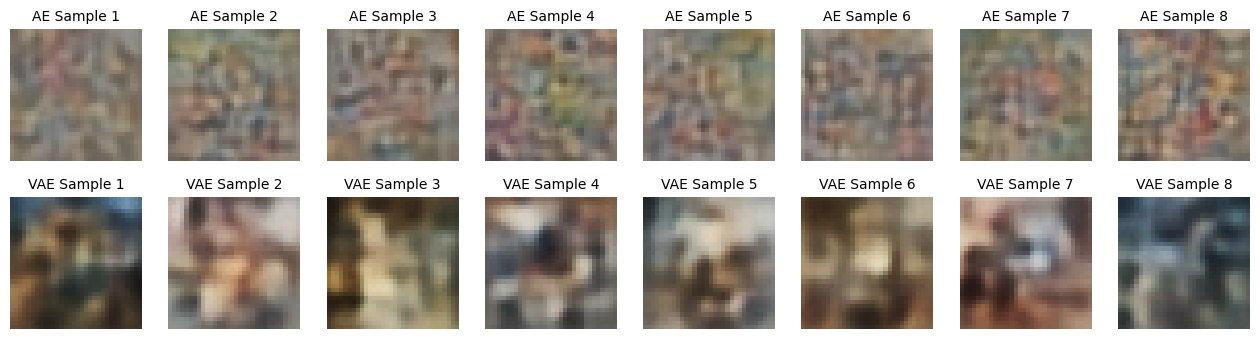

In [51]:
# SAMPLING
def compare_generation(ae_model, vae_model, z_dim, n = 8):
    ae_model.eval()
    vae_model.eval()

    # Identifichiamo le dimensioni corrette dai modelli stessi
    # (Assumendo che tu abbia salvato latent_dim come attributo della classe)
    # Se non lo hai, inseriamo i numeri fissi: 256 per AE, 128 per VAE
    z_dim_ae = 256 
    z_dim_vae = 128

    # Random noise for both models
    z_ae = torch.randn(n, z_dim_ae).to(device)
    z_vae = torch.randn(n, z_dim_vae).to(device)

    with torch.no_grad():
        # Generazione AE (decodifica diretta del rumore)
        gen_ae = ae_model.decode(z_ae).cpu().clamp(0,1)

        # Generazione VAE (decodifica diretta del rumore)
        gen_vae = vae_model.decode(z_vae).cpu().clamp(0,1)

    # Plotting
    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        axes[0, i].imshow(gen_ae[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[0, i].set_title(f"AE Sample {i+1}", fontsize=10)
        
        
        axes[1, i].imshow(gen_vae[i].permute(1, 2, 0))
        axes[1, i].axis('off')
        axes[1, i].set_title(f"VAE Sample {i+1}", fontsize=10)

    plt.show()

best_vae = ConvVAE(latent_dim=128, base_filters=64).to(device)
best_vae.load_state_dict(torch.load('/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/convvae_z128_lr0_0005_f64_e20_b0_1.pth'))
compare_generation(best_model, best_vae, z_dim = 128)

This figure illustrates the fundamental difference between a standard **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** when **generating new content from random noise**
- **AE Samples**: The image generated by AE appear as inconsistent with very little structural or color diversity. This occurs because the AE latent space is **unregularized** and **discontinuous**. When we sample a random vector, the decoder lands in "holes" in latent space that were never populated during training.
- **VAE Samples**: The VAE produces samples with distinct colors and recognizable artistic compositions. Although the images remain somewhat blurry due to the MSE loss, they exhibit **semantic coherence**. This is the result of the **KL Divergence** constraint, which forces the latent space into a continuous Gaussian distribution, ensuring that every point in the space maps to a realistic feature of the ArtBench dataset.

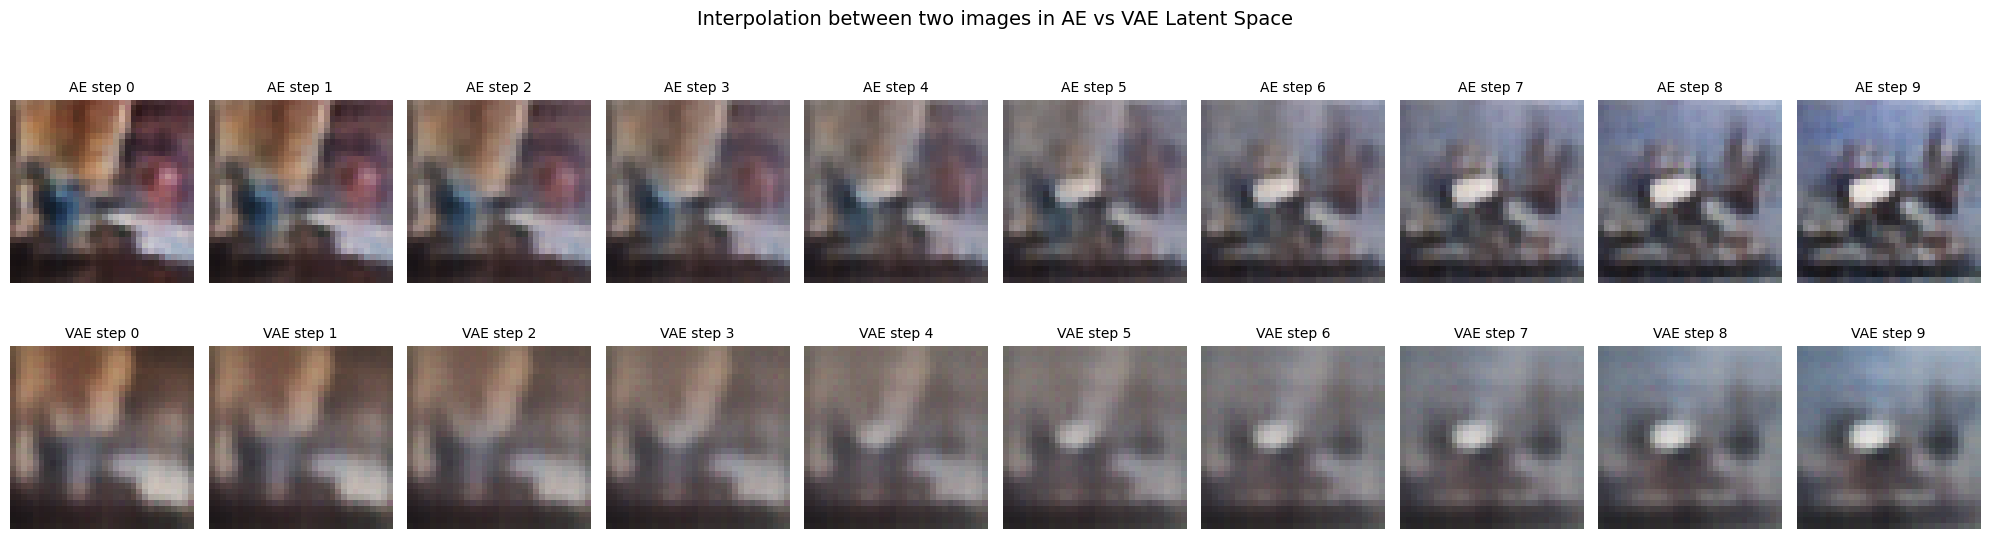

In [62]:
def compare_interpolation(ae_model, vae_model, loader, n_steps=10):
    ae_model.eval()
    vae_model.eval()

    # 1. Prendiamo due immagini reali
    images, _, _ = next(iter(loader))
    start = images[0:1].to(device)  # Prima immagine
    end = images[1:2].to(device)  # Seconda immagine 

    alphas = torch.linspace(0, 1, steps=n_steps).to(device)


    
    with torch.no_grad():

        # AE interpolation
        z_start_ae = ae_model.encode(start)
        z_end_ae = ae_model.encode(end)

        interp_ae = []
        for a in alphas:
            z_interp = (1 - a) * z_start_ae + a * z_end_ae
            interp_ae.append(ae_model.decode(z_interp))
        interp_ae = torch.cat(interp_ae, dim=0).cpu().clamp(0,1)

        # VAE interpolation
        mu_start, _ = vae_model.encode(start)
        mu_end, _ = vae_model.encode(end)

        interp_vae = []
        for a in alphas:
            z_interp = (1 - a) * mu_start + a * mu_end
            interp_vae.append(vae_model.decode(z_interp))
        interp_vae = torch.cat(interp_vae, dim=0).cpu().clamp(0,1)
    
    # Plotting
    fig, axes = plt.subplots(2, n_steps, figsize=(n_steps * 2, 6))
    for i in range(n_steps):
        axes[0, i].imshow(interp_ae[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[0, i].set_title(f"AE step {i}", fontsize=10)
        
        axes[1, i].imshow(interp_vae[i].permute(1, 2, 0))
        axes[1, i].axis('off')
        axes[1, i].set_title(f"VAE step {i}", fontsize=10)
    
    plt.suptitle("Interpolation between two images in AE vs VAE Latent Space", fontsize=14)
    plt.tight_layout()
    plt.show()

compare_interpolation(best_model, best_vae, train_loader_from_csv, n_steps=10)


### Latent Space Interpolation Analysis: AE vs. VAE
The provided image visualizes a comparative study of **latent space continuity** between a standard **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** trained on the ArtBench dataset. By performing a *linear interpolation* between the latent representations of two distinct images, we can evaluate how each model structures its internal understanding of the data.

1. #### Standard Autoencoder
    The interpolation sequence of AE shows **structural instability**. While the model transitions from the first to the last image, the intermediate steps (Steps 3 through 6) show abrupt changes and "ghosting" artifacts. The main reason is for the **unregularized latent space**. Because the AE does not force its latent vectors into a continuous distribution, the space between encoded data points is often "empty." When the decoder is forced to interpret these unknown regions, it produces incoherent or visually fractured results, as seen in the sharp flickering of colors and shapes.

2. #### Variational Autoencoder
    The VAE sequence demonstrates superior **semantic morphing** and **fluid transitions**. The shift from the warm, dark tones of Step 0 to the cooler, blueish hues of Step 9 happens gradually across the manifold. The main reason is for the **KL Divergence** constraint. By forcing the latent space to follow a Gaussian distribution, the VAE ensures **manifold continuity**. Every intermediate point between two images is mathematically "meaningful" to the decoder, allowing it to generate plausible hybrid features (blending light, color, and texture) rather than just overlapping pixels.

----------------------------------------------------------------------------------------------------

## DCGAN (Deep Convolutional GAN)

#### Generator
Transform a vector of noise into an image 32x32 (that seems real), try to fool the Discriminator

In [16]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        # ngf = number of generator filters (base) 
        super().__init__()
        self.latent_dim = latent_dim

        # Input: latent_dim x 1 x 1
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: ngf * 4 x 4 x 4
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: ngf * 2 x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: ngf x 16 x 16
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            
            # Convert values in [-1, 1]
            nn.Tanh()
            # Output size: image_channels x 32 x 32
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)  # reshape to (B, latent_dim, 1, 1)
        return self.model(z)

#### Discriminator

The goal is to see the image and understand if is **true** or **false**


In [17]:
class Discriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            # Input: {image_channels} x 32 x 32
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: {ndf} x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: {ndf * 2} x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: {ndf * 4} x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1,1)

In [18]:
def init_dcgan_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

### Training Loop

In [19]:
def train_gan(generator, discriminator, dataloader, latent_dim, opt_g, opt_d, num_epochs=20, lr=2e-4):
    criterion = nn.BCELoss()

    history = {
        'gen_loss': [],
        'disc_loss': []
    }

    generator.train()
    discriminator.train()

    for epoch in range(num_epochs):
        gen_loss = 0.0
        disc_loss = 0.0
        n_batches = 0
        for real_imgs, _, _ in dataloader:
            real_img = real_imgs.to(device)
            batch_size = real_img.size(0)

            real_targets = torch.ones(batch_size, 1).to(device)
            fake_targets = torch.zeros(batch_size, 1).to(device)

            # --- Train Discriminator ---
            opt_d.zero_grad()

            # Real images
            real_output = discriminator(real_img)
            d_loss_real = criterion(real_output, real_targets)

            # Fake images
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_img = generator(z)
            fake_output = discriminator(fake_img.detach())
            d_loss_fake = criterion(fake_output, fake_targets)

            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake

            d_loss.backward()
            opt_d.step()

            # --- Train Generator ---
            opt_g.zero_grad()

            z = torch.randn(batch_size, latent_dim).to(device)
            fake_img = generator(z)
            output = discriminator(fake_img)
            g_loss = criterion(output, real_targets)  # Generator wants discriminator to predict real

            g_loss.backward()
            opt_g.step()

            gen_loss += g_loss.item()
            disc_loss += d_loss.item()
            n_batches += 1
        
        history['gen_loss'].append(gen_loss / n_batches)
        history['disc_loss'].append(disc_loss / n_batches)

        print(f"Epoch {epoch+1}/{num_epochs} - Gen Loss: {history['gen_loss'][-1]:.4f}, Disc Loss: {history['disc_loss'][-1]:.4f}")
    
    return history

In [20]:
import itertools
gan_search_space = {
    'z': [100, 128],
    'lr': [(2e-4, 2e-4), (1e-4, 4e-4)],  # (lr_gen, lr_disc)
    'epochs': [20],
    'filters': [(64, 64), (128, 64), (32, 64)]
}

keys = gan_search_space.keys()
values = gan_search_space.values()
combinations = list(itertools.product(*values))

gan_configs = []
for combo in combinations:
    config = dict(zip(keys, combo))
    ngf, ndf = config['filters']
    lrg, lrd = config['lr']
    config['name'] = f"DCGAN_z{config['z']}_lrG{config['lr'][0]}_lrD{config['lr'][1]}_ngfG{config['filters'][0]}_ngfD{config['filters'][1]}_e{config['epochs']}"
    gan_configs.append(config)

print(f"Ready to test {len(gan_configs)} GAN configurations:")
for cfg in gan_configs:
    print(f" - {cfg['name']}")

Ready to test 12 GAN configurations:
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
 - DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20
 - DCGAN_z100_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e20
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
 - DCGAN_z128_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
 - DCGAN_z128_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20
 - DCGAN_z128_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20
 - DCGAN_z128_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e20


In [27]:
train_loader_gan, _ = build_artbench_loaders(
    train_hf,
    test_hf,
    train_ids=train_ids_from_csv,
    use_gan_norm=True
)


all_gan_results = {}
N_SAMPLES = 2000 # Numero immagini per il FID

for idx, cfg in enumerate(gan_configs):
    print(f"\n🎮 CONFIG {idx+1}/{len(gan_configs)}: {cfg['name']}")

    # Check if model already exists
    ckpt_path = Path(f"/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/{cfg['name']}.pth")
    #ckpt_path = Path(f"/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/{cfg['name']}.pth")
    
    #print(f"DEBUG: Sto cercando il file in: {ckpt_path}") # <--- AGGIUNGI QUESTA
    #print(f"DEBUG: Il file esiste? {ckpt_path.exists()}") # <--- E QUESTA

    ngf, ndf = cfg['filters']
    lrg, lrd = cfg['lr']
    latent_dim = cfg['z']

    # 1. Istanza Modelli
    netG = Generator(latent_dim=latent_dim, ngf=ngf).to(device)
    netD = Discriminator(ndf=ndf).to(device)

    # UPDATE or TRAINING
    if ckpt_path.exists():
        print(f"Model checkpoint found for {cfg['name']}. Loading model...")
        checkpoint = torch.load(ckpt_path)
        netG.load_state_dict(checkpoint['generator'])
        netD.load_state_dict(checkpoint['discriminator'])
        history = checkpoint['history']
    else:
        print(f"No checkpoint found for {cfg['name']}. Starting training...")
        
        init_dcgan_weights(netG)
        init_dcgan_weights(netD)

        # 3. Ottimizzatori con i parametri del prof
        opt_g = torch.optim.Adam(netG.parameters(), lr=lrg, betas=(0.5, 0.999))
        opt_d = torch.optim.Adam(netD.parameters(), lr=lrd, betas=(0.5, 0.999))

        # 4. Training (usando la tua funzione train_gan)
        history = train_gan(
            generator=netG, 
            discriminator=netD, 
            dataloader=train_loader_gan, 
            latent_dim=cfg['z'], 
            num_epochs=cfg['epochs'],
            opt_g=opt_g,
            opt_d=opt_d
        )

        # Save model after training
        save_gan_model(netG, netD, history, cfg, ckpt_dir="/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models")
        
    
    
    # Pulizia
    del netG, netD
    torch.cuda.empty_cache()

Preprocessing: using GAN normalization ([-1,1])
Notebook kernel detected: forcing num_workers=0 for DataLoader stability.

🎮 CONFIG 1/12: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20. Loading model...

🎮 CONFIG 2/12: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20. Loading model...

🎮 CONFIG 3/12: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20. Loading model...

🎮 CONFIG 4/12: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20. Loading model...

🎮 CONFIG 5/12: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20
Model checkpoint found for DCGAN_z100_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20. Loading model...

🎮 CONFIG 6/12: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e20
Model checkpoi

In [31]:
import pandas as pd

# 1. Preparazione Immagini Reali (Riferimento)
# Usiamo il loader con use_gan_norm=True e riportiamo in [0,1] uint8
real_images_gan_norm = collect_real_images_from_loader(train_loader_gan, max_images=N_SAMPLES)
# Riportiamo da [-1, 1] a [0, 1] prima di convertire in uint8
real_images_gan_norm = denorm(real_images_gan_norm)
real_uint8 = to_uint8_artbench10(real_images_gan_norm.cpu())

all_gan_results = {}
best_fid = float('inf')
best_cfg_name = ""
idx = 0

print(f"\nEvaluation of {len(gan_configs)} GANs configurations...")

for cfg in gan_configs:
    idx = idx + 1
    print(f"\n CONFIGURATION {idx}/{len(gan_configs)}: {cfg['name']}")

    ckpt_path = Path(f"/content/drive/MyDrive/GenerativeAI/GenAI_Project/Models/{cfg['name']}.pth")
    
    if not ckpt_path.exists():
        continue

    # 2. Upload Model
    checkpoint = torch.load(ckpt_path, map_location=device)
    netG = Generator(latent_dim=cfg['z'], ngf=cfg['filters'][0]).to(device)
    netG.load_state_dict(checkpoint['generator'])
    netG.eval()

    # 3. Generazione Fake specifica per GAN
    # Le DCGAN di solito si aspettano un noise 4D: (batch, z, 1, 1)
    with torch.no_grad():
        noise = torch.randn(N_SAMPLES, cfg['z'], 1, 1, device=device)
        gen_images = netG(noise)
        # Portiamo in [0, 1] per la metrica
        gen_images = denorm(gen_images)
    
    gen_uint8 = to_uint8_artbench10(gen_images.cpu())

    # 4. Calcolo FID e KID (usando torch_fidelity o la tua funzione compute_fid)
    # Assumiamo che compute_fid chiami internamente torch_fidelity
    fid_val, kid_val = compute_fid(real_uint8, gen_uint8)
    
    all_gan_results[cfg['name']] = {
        'fid': fid_val,
        'kid': kid_val
    }

    if fid_val < best_fid:
        best_fid = fid_val
        best_cfg_name = cfg['name']

    del netG
    torch.cuda.empty_cache()

# --- STAMPA TABELLA FINALE ---
print("\n" + "="*70)
print(f"{'GAN CONFIGURATION':<50} | {'FID (↓)':<10} | {'KID (↓)':<10}")
print("-" * 70)
for name, res in all_gan_results.items():
    print(f"{name:<50} | {res['fid']:>10.2f} | {res['kid']:>10.4f}")
print("="*70)

print(f"\n🏆BEST MODEL: {best_cfg_name}")
print(f"📊 BEST FID: {best_fid:.2f}")


Evaluation of 12 GANs configurations...

 CONFIGURATION 1/12: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



 CONFIGURATION 2/12: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20

 CONFIGURATION 3/12: DCGAN_z100_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20

 CONFIGURATION 4/12: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20

 CONFIGURATION 5/12: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20

 CONFIGURATION 6/12: DCGAN_z100_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e20

 CONFIGURATION 7/12: DCGAN_z128_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20

 CONFIGURATION 8/12: DCGAN_z128_lrG0.0002_lrD0.0002_ngfG128_ngfD64_e20

 CONFIGURATION 9/12: DCGAN_z128_lrG0.0002_lrD0.0002_ngfG32_ngfD64_e20

 CONFIGURATION 10/12: DCGAN_z128_lrG0.0001_lrD0.0004_ngfG64_ngfD64_e20

 CONFIGURATION 11/12: DCGAN_z128_lrG0.0001_lrD0.0004_ngfG128_ngfD64_e20

 CONFIGURATION 12/12: DCGAN_z128_lrG0.0001_lrD0.0004_ngfG32_ngfD64_e20

GAN CONFIGURATION                                  | FID (↓)    | KID (↓)   
----------------------------------------------------------------------
DCGAN_z100_lrG0.0002_lrD0.0002_ngfG64_ngfD64_e20   |     108.52

### Comparison between Best AE vs. Best VAE vs. Best GAN

In [34]:
gan_fid = all_gan_results[best_cfg_name]['fid']
gan_kid = all_gan_results[best_cfg_name]['kid']



----------------------------------------------------------------------------------------------------------------------------------------------------

## Diffusion Models

#### Schedule and Forward Diffusion Helpers


In [ ]:
class GaussianDiffusion:
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device

        # Linear beta scheduler
        # start few noise
        # end lot of noise


        # beta : how many noise we add at each step
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)

        # alphas : how much of the original image we keep at each step
        self.alphas = 1. - self.betas

        # cumulative product of alphas (how much of the original image we keep after t steps)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # for have [1.0, alpha_bar_0, alpha_bar_1, ..., alpha_bar_{T-1}]
        self.alphas_cumprod_prev = torch.cat([
            torch.tensor([1.]).to(device), # Add 1 at the beginning for t=0
            self.alphas_cumprod[:-1] # Take all but the last element for t=1 to T

        ])

        # FORWARD DIFFUSION -> Transform image into noise
        # we need to compute:
        # - sqrt(alpha_cumprod) for scaling the original image
        # - sqrt(1 - alpha_cumprod) for scaling the noise
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

        # REVERSE DIFFUSION -> Transform noise into image $q(x_{t-1} | x_t, x_0)$
        # Distribution of x_{t-1} given x_t and x_0 is a Gaussian with mean and variance:

        # - POSTERIOR MEAN
        #   - posterior_mean_coef1 = is the weight given for x_0 in the calculation of the mean. 
        #                             More near to the start, more highter is the weight for x_0, because we have less noise
        #   - posterior_mean_coef2 = is the weight given for x_t in the calculation of the mean.
        #                             More near to the end, more highter is the weight for x_t, because we have more noise
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)

        # - POSTERIOR VARIANCE
        #   - posterior_variance = is the variance of the distribution of x_{t-1} given x_t and x_0. 
        #                          More near to the end, more highter is the variance, because we have more noise
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

        """
        Take clear image and insert noise at step t
        """
        def q_sample(self, x_0, t, noise=None):
            # x_0: original image
            # t: timestep
            # noise: if we want to specify the noise, otherwise it will be sampled from a normal distribution
            if noise is None:
                noise = torch.randn_like(x_0)
            
            # take the coefficients for the given timestep t
            sqrt_alpha_prod = self._get_index(self.sqrt_alphas_cumprod, t, x_0.shape)
            sqrt_one_minus_alpha_prod = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)

            return sqrt_alpha_prod * x_0 + sqrt_one_minus_alpha_prod * noise

        """
        Remove some noise from the image at step t, given the predicted noise
        """
        @torch.no_grad()
        def p_sample(self, model, x, t, t_index):
            # model: the noise predictor model
            # x: the noisy image at step t
            # t: the current timestep
            # t_index: the index of the current timestep (0 to num_timesteps-1)

            # recover the coefficients for the current timestep
            betas_t = self._get_index(self.betas, t, x.shape)
            sqrt_one_minus_alpha_cumprod_t = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
            sqrt_recip_alphas_t = 1. / torch.sqrt(self._get_index(self.alphas, t, x.shape))

            # predict the noise using the model
            predicted_noise = model(x, t)

            model_mean = sqrt_recip_alphas_t * (x - betas_t * predicted_noise / sqrt_one_minus_alpha_cumprod_t)

            if t_index == 0:
                return model_mean
            else:
                # Add some noise for the stochasticity of the reverse process
                posterior_variance_t = self._get_index(self.posterior_variance, t, x.shape)
                noise = torch.randn_like(x)
                return model_mean + torch.sqrt(posterior_variance_t) * noise
        
        """
        Function that generate the images
        INPUT:
        - model == network who predicts the noise
        - shape == shape of the batch (batch_size, 3, 32, 32) --> RGB images
        """
        @torch.no_grad()
        def p_sample_loop(self, model, shape):
            # Sample all steps from pure noise to reconstruct an image in latent space
            model.eval()

            # start with noise x_T
            x = torch.randn(shape).to(self.device)

            # reverse from T-1 back to 0
            for i in reversed(range(0, self.num_timesteps)):

                # make a vector (tensor) of size = batch_size (shape[0])
                # where each element has the actual step value i
                t = torch.full((shape[0], ), i, dtype=torch.long).to(self.device)

                # denoising pass
                x = self.p_sample(model, x, t, i)
            
            return x

        def _get_index(self, tensor, t, x_shape):
            # x_shape = (64, 3, 32, 32)
            # tensor = vector with all the noises --> shape (num_timesteps, )
            # t = index t of the timesteps for all the images

            # EXAMPLE t = [10, 44, 100, 200, ....] ---> out = [beta_10, beta_44, beta_100, beta_200, ....] until 64 noises
            out = tensor.gather(-1, t)

            # BROADCASTING
            # from (64, 3, 32, 32) --> (64, 1, 1, 1)
            return out.view(t.shape[0], *((1, ) * (len(x_shape) - 1)))





### Denoiser Network

In [ ]:
import math
# Transformation of the timestep t (scalar) into a vector with a lot of informations
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Final dimension of the embedding vector
        self.dim = dim
    
    def forward(self, x):
        # x represent the timestep t
        
        device = x.device

        # To create a balanced embedding of sin and cos, we work with half of dimension
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)

        # Generate a sequence of exp decaying frequencies
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)

        # Multiply the timestep t by each frequency generated
        emb = x[:, None] * emb[None, :]

        # Apply sin and cos to the phases and concatenate them
        # The final vector is [sin(f1*t), ..., sin(fn*t), cos(f1*t), ..., cos(fn*t)]
        # This allows the model to capture both high-frequency (fast changes) 
        # and low-frequency (slow changes) patterns in time.
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)

        return emb
    
class ResnetBlock(nn.Module):

    """
    Core building block of the Diffusion model: a ResNet block conditioned on time.
    It combines image features with temporal information to modulate noise prediction.
    """
    
    def __init__(self, dim, time_emb_dim, out_dim=None):
        super.__init__()
        # If out_dim is not specified, keep the same number of channels
        self.out_dim = out_dim or dim

        # TIME EMBEDDING PROJECTION:
        # Projects the global time embedding into local feature dimension
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, self.out_dim)
        )

        # CONVOLUTIONAL LAYERS
        # conv1 = initial feature extraction and channel transformation (if dimensions are different)
        self.conv1 = nn.Conv2d(dim, self.out_dim, 3, padding=1)
        # conv2 = Refines features after time information has been injected
        self.conv2 = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)

        # NORMALIZATION LAYERS
        self.norm1 = nn.GroupNorm(4, dim)
        self.norm2 = nn.GroupNorm(4, self.out_dim)
        self.act = nn.SiLU()

        # Shortcut Connection (Residual):
        # If input and output dimensions differ, use a 1x1 conv to match them
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, time_emb):
        
        """
        x: Input feature map [Batch, Channels, Height, Width]
        time_emb: Global time embedding [Batch, time_emb_dim]
        """
        # First step: Feature Extraction
        h = self.norm1(x)
        h = self.act(h)

        h = self.conv1(h) # Example [B, 32, 32, 32] -> [B, 64, 32, 32]

        # Second step: Time Injection
        # Project the time emb to match the image channels
        time_emb = self.mlp(time_emb)
        # Reshape [B, C] -> [B, C, 1, 1] for broadcasting

        # Add time info to every pixel: every cell now knows the current noise
        h = h + time_emb[:, :, None, None]

        # Third Step: Refinement
        h = self.norm2(h)
        h = self.act(h)
        h = self.conv2(h)

        # Combined processed features with the original input (Residual connection)
        return self.shortcut(x) + h


"""
Predicts the noise inside the Latent Space
"""
class LatentDenoiseNetwork(nn.Module):
    """
    Denoising network operating on latent tensors of shape [B, latent_channels, H_lat, W_lat]
    """
    # Assume that AE compress images from (64, 3, 32, 32) into (64, 4, 8, 8)

    def __init__(self, latent_channels=4, model_channels=64, num_res_blocks=3):
        super().__init__()

        # Transforms the step number t into a vector with some useful informations
        # TIME EMBEDDING

        self.time_emb = nn.Sequential(
            # INPUT = vector t of shape (B, ) -> batch_size scalar numbers
            # SinusoidalPosEmb transforms each scalar into a vector of dimension model_channels = 64
            # Now I have 64 vectors of dimension 64
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            # now [64, 64] --> [64, 256]
            nn.Linear(model_channels * 4, model_channels * 4),
        )

        # OUTPUT = time_emb = [B, 256]

        # Start into latent space
        # [B, 4, H, W] -> [B, 64, H, W]
        self.init_conv = nn.Conv2d(latent_channels, model_channels, 3, padding=1)

        """
        RESIDUAL BLOCKS
        Create a list of the type [Block1, Block2, Block3]
        Each block takes:
            x -> [B, 64, H, W]
            time_emb -> [B, 256]
        """
        self.res_blocks = nn.ModuleList([
            ResnetBlock(model_channels, model_channels * 4)
            for _ in range(num_res_blocks)
        ])

        #End latent space
        # [B, 64, H, W] -> [B, 4, H, W]
        self.out_conv = nn.Conv2d(model_channels, latent_channels, 3, padding=1)
    

    def forward(self, x, t):
        """
            INPUT
                x -> [B, 4, H, W]
                t -> [B]
        """

        # Convert [B] into [B, 256]
        t_emb = self.time_emb(t)

        # Convert [64, 4, 8, 8] into [64, 64, 8, 8]
        h = self.init_conv(x)
        for block in self.res_blocks:
            h = block(h, t_emb)
        
        # Return [64, 4, 8, 8]
        return self.out_conv(h)


class PixelUNet(nn.Module):

    def __init__(self, in_channels=3, model_channels=64):
        super().__init__()

        # Time embedding
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            nn.Linear(model_channels * 4, model_channels * 4),
        )

        # [B] -> [B, 256]

        # time_dim = 256
        time_dim = model_channels * 4

        # Initial Conv
        # Transformation from [64, 3, 32, 32] --> [64, 64, 32, 32]
        self.init_conv = nn.Conv2d(in_channels, model_channels, 3, padding=1)

        # DOWNSAMPLING
        # 1) Decrease the spatial dimension
        # 2) Increase the number of channels

        # From 32 to 16
        self.down1_res = ResnetBlock(model_channels, time_dim)

        # [64, 64, 32, 32] --> [64, 64, 16, 16]
        self.down1_pool = nn.Conv2d(model_channels, model_channels, 3, stride=2, padding=1)

        # From 16 to 8

        # [64, 64, 16, 16] -> [64, 128, 16, 16]
        self.down2_res = ResnetBlock(model_channels, time_dim, out_dim=model_channels * 2)

        # [64, 128, 16, 16] -> [64, 128, 8, 8]
        self.down2_pool = nn.Conv2d(model_channels * 2, model_channels * 2, 3, stride=2, padding=1)

        # Middle
        self.mid_res1 = ResnetBlock(model_channels * 2, time_dim)
        self.mid_res2 = ResnetBlock(model_channels * 2, time_dim)


        # UPSAMPLING
        # Use the skip connections for spatial details
        
        # 8 -> 16
        # From [64, 128, 8, 8] -> [64, 64, 16, 16]
        self.up2_conv = nn.ConvTranspose2d(model_channels * 2, model_channels, 4, stride=2, padding=1)
        # Skip connection from down2_res is model_channels * 2
        # After concat: model_channels (up) + model_channels * 2 (skip) = model_channels * 3
        self.up2_res = ResnetBlock(model_channels * 3, time_dim, out_dim=model_channels)

        # 16 -> 32
        self.up1_conv = nn.ConvTranspose2d(model_channels, model_channels, 4, stride=2, padding=1)
        # Skip connection from down1_res is model_channel
        # After concat: model_channels (up) + model_channels (skip) = model_channels * 2
        self.up1_res = ResnetBlock(model_channels * 2, time_dim, out_dim=model_channels)

        self.out_conv = nn.Conv2d(model_channels, in_channels, 3, padding=1)

    def forward(self, x, t):

        t_emb = self.time_emb(t)

        # [B, 3, 32, 32]
        h_init = self.init_conv(x)

        # Down1
        h1 = self.down1_res(h_init, t_emb) # [B, 64, 32, 32]
        h1_pool = self.down1_pool(h1) # [B, 64, 16, 16]

        # Down2
        h2 = self.down2_res(h1_pool, t_emb) # [B, 128, 16, 16]
        h2_pool = self.down2_pool(h2) # [B, 128, 8, 8]

        # Middle (BOTTLENECK)
        h_mid = self.mid_res1(h2_pool, t_emb) # [B, 128, 8, 8]
        h_mid = self.mid_res2(h_mid, t_emb) # [B, 128, 8, 8]

        # Up2
        h_up2 = self.up2_conv(h_mid) # [B, 64, 16, 16]
        h_up2 = torch.cat([h_up2, h2], dim=1) # SKIP CONNECTION -> [B, 192, 16, 26]
        h_up2 = self.up2_res(h_up2, t_emb) # [B, 64, 16, 16]

        # Up1
        h_up1 = self.up1_conv(h_up2) # [B, 64, 32, 32]
        h_up1 = torch.cat([h_up1, h1], dim=1) # SKIP CONNECTION -> [B, 128, 32, 32]
        h_up1 = self.up1_res(h_up1, t_emb) # [B, 64, 32, 32]

        return self.out_conv(h_up1)
        


In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        # Latent space
        self.mu = nn.Conv2d(64, latent_channels, kernel_size=1)
        self.logvar = nn.Conv2d(64, latent_channels,  kernel_size=1)

    def forward(self, x):
        h = self.model(x)
        return self.mu(h), self.logvar(h)
    
class Decoder(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.initial_conv = nn.Conv2d(latent_channels, 64, kernel_size=1)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(64, 64,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=3, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        h = self.initial_conv(z)
        return self.model(h)
    
class VAE(nn.Module):
    def __init__(self, latent_channels=4):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

### Reverse Sampling

In [ ]:
@torch.no_grad()
def sample_diffusion(model, schedule, shape):

    model.eval()

    x = torch.randn(shape, device=device)

    # DENOISING LOOP
    for step in reversed(range(schedule['T'])):

        # current step for each image in the batch
        t = torch.full((shape[0], ), step, device=device, dtype=torch.long)

        predict_noise = model(x, t)

        # Parameters from scheduler
        alpha_t = schedule['alphas'][step]
        alpha_bar_t = schedule['alpha_bars'][step]
        beta_t = schedule['betas'][step]

        sqrt_alpha_t = torch.sqrt(alpha_t)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1. - alpha_bar_t)

        # Add final noise (if we are not in the final step)
        if step > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)
        
        # UPDATE EQUATION
        x = (
            (1. / sqrt_alpha_t) 
            * (x - ((1. - alpha_t) / sqrt_one_minus_alpha_bar_t) * predict_noise)
            + torch.sqrt(beta_t) * noise
            )
    
    return x

## Training Loops

#### Train VAE

In [ ]:
def train_autoencoder(model, loader, epochs=20, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()

    for epoch in range(epochs):
        running = 0.0
        n_batches = 0
        
        for x, _, _ in (loader):
            x = x.to(device)
            x_hat, _, _ = model(x)

            loss = 0.5 * F.mse_loss(x_hat, x) + 0.5 * F.l1_loss(x_hat, x)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item()
            n_batches += 1
        
        avg = running / n_batches
        history.append(avg)
        print(f"AE epoch {epoch + 1: 02d}/{epochs} | recon loss: {avg:.4f}")
    
    return history

#### Train Diffusion


In [ ]:
# Teach the U-Net to recognize noise
def train_diffusion(model, loader, schedule, epochs=20, lr=2e-4, encode_fn=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()



## FID Metrics

In [38]:
import torch_fidelity

def to_uint8_artbench10(x):
    # x è un tensore in [0,1], lo portiamo a [0,255] e lo convertiamo in uint8
    x = x.clamp(0, 1)
    x = (x * 255).to(torch.uint8)
    return x

def collect_real_images_from_loader(loader, max_images=5000):
    xs = []
    count = 0
    for x, _, _ in loader:
        xs.append(x)
        count += x.size(0)
        if count >= max_images:
            break
    x_all = torch.cat(xs, dim=0)[:max_images]
    return x_all

def sample_from_AE(model, loader, images=5000):
    model.eval()
    zs = []
    cont = 0

    with torch.no_grad():

        for x, _, _ in loader:
            x = x.to(device)

            # latent vector
            z = model.encode(x)
            zs.append(z.cpu())
            cont += x.size(0)
            if cont >= images:
                break
    z_all = torch.cat(zs, dim=0)[:images]

    z = z_all[torch.randperm(z_all.size(0))[:images]].to(device)  # shuffle e subset

    with torch.no_grad():
        xhat = model.decode(z).cpu().clamp(0, 1)
    return xhat

def sample_from_VAE(model, images=5000):
    model.eval()
    zs = []
    cont = 0

    with torch.no_grad():

        # random numbers from normal distribution
        z_random = torch.randn(images, model.latent_dim).to(device)

        x_hat = model.decode(z_random).cpu().clamp(0, 1)
    return x_hat



In [39]:
import tempfile
from pathlib import Path
from PIL import Image

# save images to disk for FID calculation
def save_images_for_fid(images, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for i in range(images.size(0)):
        img = images[i].permute(1, 2, 0).cpu().numpy() 
         # CxHxW -> HxWxC
        Image.fromarray(img).save(out_dir/f'{i:05d}.png')

def compute_fid(real_batch_u8, gen_batch_u8):
    with tempfile.TemporaryDirectory() as tmpdir:
        real_dir = Path(tmpdir) / 'real'
        gen_dir = Path(tmpdir) / 'gen'
        save_images_for_fid(real_batch_u8, real_dir)
        save_images_for_fid(gen_batch_u8, gen_dir)
        metrics = torch_fidelity.calculate_metrics(
            input1=str(real_dir), 
            input2=str(gen_dir), 
            cuda=torch.cuda.is_available(), 
            fid=True, 
            kid=True,
            kid_subset_size=100,
            kid_subset=50, 
            verbose=False)
    return float(metrics['frechet_inception_distance']), float(metrics['kernel_inception_distance_mean'])

In [25]:

N_REPETITIONS = 3
N_FID_SAMPLES = 5000

# List for storing results for every seed
conv_fid_scores = [] 
vae_fid_scores = []
conv_kid_scores = [] 
vae_kid_scores = []

print(f"Starting evaluation protocol (10 repetitions), {N_FID_SAMPLES} samples for FID/KID calculation each time...")

for i in range(N_REPETITIONS):
    # Change seed at every iteration for variability
    torch.manual_seed(SEED + i)

    # Prepare real and generated samples

    real = collect_real_images_from_loader(train_loader_from_csv, max_images=N_FID_SAMPLES)
    conv_gen = sample_from_AE(convolutionalAE, train_loader_from_csv, images=N_FID_SAMPLES)
    vae_gen = sample_from_VAE(convolutionalVAE, images=N_FID_SAMPLES)

    # Conversion to uint8 for FID calculation
    real_uint8 = to_uint8_artbench10(real)
    conv_uint8 = to_uint8_artbench10(conv_gen)
    vae_uint8 = to_uint8_artbench10(vae_gen)

    f_conv, k_conv = compute_fid(real_uint8, conv_uint8)
    f_vae, k_vae = compute_fid(real_uint8, vae_uint8)

    conv_fid_scores.append(f_conv)
    conv_kid_scores.append(k_conv)
    vae_fid_scores.append(f_vae)
    vae_kid_scores.append(k_vae)

    torch.cuda.empty_cache()  # libera memoria GPU dopo ogni iterazione

    print(f"Ripetizione {i+1} completata.")

# --- RISULTATI FINALI (Mean ± Std) ---
print("-" * 30)
print(f"RISULTATI FINALI (ArtBench-10, n={N_FID_SAMPLES})")
print(f"Conv AE FID: {np.mean(conv_fid_scores):.4f} ± {np.std(conv_fid_scores):.4f}")
print(f"Conv AE KID: {np.mean(conv_kid_scores):.4f} ± {np.std(conv_kid_scores):.4f}")
print("-" * 30)
print(f"VAE FID:     {np.mean(vae_fid_scores):.4f} ± {np.std(vae_fid_scores):.4f}")
print(f"VAE KID:     {np.mean(vae_kid_scores):.4f} ± {np.std(vae_kid_scores):.4f}")    


Starting evaluation protocol (10 repetitions), 5000 samples for FID/KID calculation each time...


KeyboardInterrupt: 

In [ ]:

N_REPETITIONS = 3
N_FID_SAMPLES = 5000

# List for storing results for every seed
conv_fid_scores = [] 
vae_fid_scores = []
conv_kid_scores = [] 
vae_kid_scores = []

print(f"Starting evaluation protocol (10 repetitions), {N_FID_SAMPLES} samples for FID/KID calculation each time...")

for i in range(N_REPETITIONS):
    # Change seed at every iteration for variability
    torch.manual_seed(SEED + i)

    # Prepare real and generated samples

    real = collect_real_images_from_loader(train_loader_from_csv, max_images=N_FID_SAMPLES)
    conv_gen = sample_from_AE(convolutionalAE, train_loader_from_csv, images=N_FID_SAMPLES)
    vae_gen = sample_from_VAE(convolutionalVAE, images=N_FID_SAMPLES)

    # Conversion to uint8 for FID calculation
    real_uint8 = to_uint8_artbench10(real)
    conv_uint8 = to_uint8_artbench10(conv_gen)
    vae_uint8 = to_uint8_artbench10(vae_gen)

    f_conv, k_conv = compute_fid(real_uint8, conv_uint8)
    f_vae, k_vae = compute_fid(real_uint8, vae_uint8)

    conv_fid_scores.append(f_conv)
    conv_kid_scores.append(k_conv)
    vae_fid_scores.append(f_vae)
    vae_kid_scores.append(k_vae)

    torch.cuda.empty_cache()  # libera memoria GPU dopo ogni iterazione

    print(f"Ripetizione {i+1} completata.")

# --- RISULTATI FINALI (Mean ± Std) ---
print("-" * 30)
print(f"RISULTATI FINALI (ArtBench-10, n={N_FID_SAMPLES})")
print(f"Conv AE FID: {np.mean(conv_fid_scores):.4f} ± {np.std(conv_fid_scores):.4f}")
print(f"Conv AE KID: {np.mean(conv_kid_scores):.4f} ± {np.std(conv_kid_scores):.4f}")
print("-" * 30)
print(f"VAE FID:     {np.mean(vae_fid_scores):.4f} ± {np.std(vae_fid_scores):.4f}")
print(f"VAE KID:     {np.mean(vae_kid_scores):.4f} ± {np.std(vae_kid_scores):.4f}")    
